In [89]:
import pandas as pd
import seaborn as sns
import numpy as np

In [90]:
df = pd.read_csv("data_3_1_1.csv")

<Axes: xlabel='x1', ylabel='x2'>

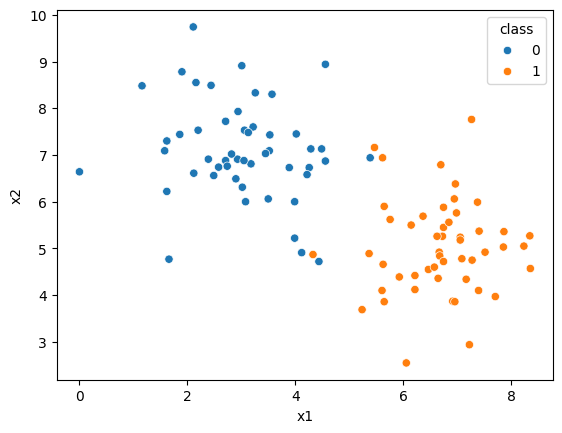

In [91]:
sns.scatterplot(x=df["x1"],y=df["x2"],hue="class",data=df)

In [92]:
# split data
data = df.to_numpy()
X = data[:, :2]
y = data[:, 2]
print(X.shape)
print(y.shape)

X_train = X[:70]
y_train = y[:70]
X_test = X[70:]
y_test = y[70:]
print(X_train.shape)
print(X_test.shape)

(100, 2)
(100,)
(70, 2)
(30, 2)


In [93]:
# Feature scaling
Mean_X_train = np.mean(X_train, axis=0)
Std_x_train = np.std(X_train, axis=0)
X_train_scaled = (X_train - Mean_X_train) / Std_x_train
X_test_scaled = (X_test - Mean_X_train) / Std_x_train
print(X_train_scaled[:5])

[[ 0.98679611  0.53980269]
 [ 1.09988333 -1.48693628]
 [ 1.58821449 -0.45274414]
 [-0.95110755  0.62309333]
 [ 0.97137513 -0.75814316]]


In [94]:
# Concate 1 to X_train
X_train_new = np.concatenate((np.ones((X_train_scaled.shape[0], 1)),
                              X_train_scaled), axis=1)
print(X_train_new[:5])

[[ 1.          0.98679611  0.53980269]
 [ 1.          1.09988333 -1.48693628]
 [ 1.          1.58821449 -0.45274414]
 [ 1.         -0.95110755  0.62309333]
 [ 1.          0.97137513 -0.75814316]]


In [95]:
# change y=0 to y=-1
y_train[y_train == 0] = -1
print(y_train)

[ 1.  1.  1. -1.  1.  1. -1. -1.  1. -1.  1.  1. -1. -1. -1.  1.  1. -1.
 -1. -1. -1. -1.  1.  1.  1. -1. -1. -1. -1.  1.  1.  1. -1. -1. -1. -1.
 -1.  1.  1.  1.  1. -1.  1. -1. -1. -1.  1.  1.  1.  1. -1.  1. -1. -1.
  1. -1. -1. -1. -1. -1.  1.  1.  1.  1. -1. -1.  1.  1.  1. -1.]


In [96]:
# Hypothesis function
import numpy as np
def hypothesis(theta, X):
    return np.dot(X, theta)

In [97]:
# hinge loss function
def hinge_loss(theta, lam_da, X, y):
    z = hypothesis(theta, X)
    loss = np.mean(np.maximum(0, 1 - y * z)) + (lam_da / 2) * np.sum(theta[1:] ** 2)
    return loss


In [98]:
# Gradient function
def gradient(theta, lam_da, X, y):
    z = hypothesis(theta, X)
    grad = np.mean(-y * X.T * (1 - y * z > 0), axis=1) + 2 * lam_da * theta
    return grad


In [99]:
# Training
theta = np.zeros(X_train_new.shape[1])
lam_da = 0.1
learning_rate = 0.1

for i in range(1, 1001):
  z = hypothesis(theta, X_train_new)
  loss = hinge_loss(theta, lam_da, X_train_new, y_train)
  grad = gradient(theta, lam_da, X_train_new, y_train)
  theta = theta - learning_rate * grad
  if i % 10 == 0:
    print(f"Iteration {i:04d}: Loss = {loss:.4f}")


Iteration 0010: Loss = 0.2746
Iteration 0020: Loss = 0.2224
Iteration 0030: Loss = 0.2127
Iteration 0040: Loss = 0.2098
Iteration 0050: Loss = 0.2073
Iteration 0060: Loss = 0.2062
Iteration 0070: Loss = 0.2055
Iteration 0080: Loss = 0.2050
Iteration 0090: Loss = 0.2046
Iteration 0100: Loss = 0.2044
Iteration 0110: Loss = 0.2042
Iteration 0120: Loss = 0.2040
Iteration 0130: Loss = 0.2040
Iteration 0140: Loss = 0.2040
Iteration 0150: Loss = 0.2040
Iteration 0160: Loss = 0.2041
Iteration 0170: Loss = 0.2041
Iteration 0180: Loss = 0.2042
Iteration 0190: Loss = 0.2041
Iteration 0200: Loss = 0.2042
Iteration 0210: Loss = 0.2041
Iteration 0220: Loss = 0.2041
Iteration 0230: Loss = 0.2041
Iteration 0240: Loss = 0.2042
Iteration 0250: Loss = 0.2041
Iteration 0260: Loss = 0.2040
Iteration 0270: Loss = 0.2040
Iteration 0280: Loss = 0.2041
Iteration 0290: Loss = 0.2041
Iteration 0300: Loss = 0.2041
Iteration 0310: Loss = 0.2042
Iteration 0320: Loss = 0.2041
Iteration 0330: Loss = 0.2042
Iteration 

In [100]:
# Calculate accuracy on test set
X_test_new = np.concatenate((np.ones((X_test_scaled.shape[0], 1)),
                              X_test_scaled), axis=1)

z_test = hypothesis(theta, X_test_new)
y_pred = np.sign(z_test)
y_pred[y_pred == -1] = 0
#print(y_pred)

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy on test set: {accuracy * 100:.2f}%")

Accuracy on test set: 100.00%


In [101]:
# Calculate accuracy on training set
z_train = hypothesis(theta, X_train_new)
y_pred = np.sign(z_train)
#print(y_pred)

accuracy = np.mean(y_pred == y_train)
print(f"Accuracy on train set: {accuracy * 100:.2f}%")

Accuracy on train set: 97.14%
